# 심화 세션 - 시계열 사전과제

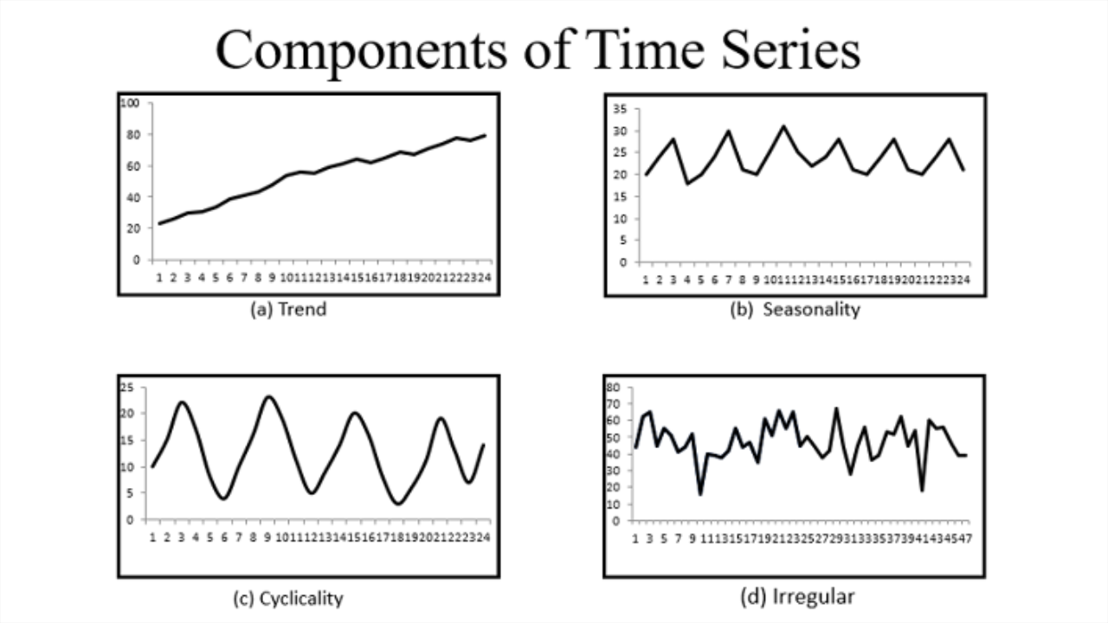

---

## 1. 시계열 데이터란?

### 1-1. 정의

**시계열 데이터**는 시간 순서대로 기록된 데이터임.

핵심은 **"순서가 의미를 가진다"** 는 점임. 일반적인 테이블 데이터는 행 순서를 바꿔도 상관없지만, 시계열의 경우 순서를 바꾸는 순간 의미가 완전히 달라짐

ex)
- 주식 가격 (매일)
- 기온 변화 (매시간)
- 월별 판매량
- 심전도 데이터

### 1-2. 시계열 데이터의 특성

시계열 데이터는 일반 데이터와 다른 독특한 특성들이 있음.

| 특성 | 설명 |
|------|------|
| **자기상관성** | 현재 값이 과거 값에 영향을 받음. "어제 더웠으면 오늘도 더울 가능성이 높다" |
| **추세** | 데이터가 장기적으로 증가하거나 감소하는 방향성 |
| **계절성** | 특정 주기로 반복되는 패턴. 여름마다 에어컨 판매량 급증 같은 것 |
| **불규칙성** | 추세나 계절성으로 설명 안 되는 랜덤한 변동 |

### 1-3. 시계열 데이터의 분석 요인

시계열 데이터는 보통 아래 4가지 요인의 조합으로 이루어졌다고 봄.

```
시계열 데이터
 ├── 추세   : 장기적인 방향성
 ├── 계절성 : 주기적으로 반복되는 패턴
 ├── 순환   : 계절성과 비슷하지만 주기가 불규칙함 (경기 사이클 등)
 └── 불규칙 : 나머지 설명 안 되는 노이즈
```

분석의 목표는 이 요인들을 잘 분리해서 **패턴을 이해하고 미래를 예측**하는 것임.

---

## 2. 시계열 데이터 전처리

시계열도 결국 데이터라서 분석 전에 손봐야 할 것들이 꽤 있음

### 2-1. 결측치 / 이상치 처리

**결측치 처리:**

일반 데이터처럼 그냥 평균값으로 채우면 안 됨. 시계열은 순서가 중요하기 때문에 **앞뒤 값을 고려**해야 함.

| 방법 | 설명 |
|------|------|
| **전방 채우기** | 바로 앞 시점의 값으로 채움 |
| **후방 채우기** | 바로 뒤 시점의 값으로 채움 |
| **선형 보간** | 앞뒤 값 사이를 선형으로 이어서 채움. 가장 자연스러움 |
| **이동 평균** | 주변 시점들의 평균으로 채움 |


```

**이상치 처리:**

시계열 이상치는 두 종류로 볼 수 있음.
- **진짜 이상치**: 측정 오류, 입력 실수 → 제거하거나 보간
- **의미 있는 이상치**: 실제로 발생한 급격한 변화 (코로나로 인한 매출 급락 등) → 함부로 제거하면 안 됨

IQR이나 Z-score 같은 통계적 방법으로 이상치를 탐지하고, **왜 이상치인지 먼저 파악**하는 게 중요함.

### 2-2. EDA

시계열 EDA는 일반 EDA랑 조금 다름. **시간 흐름에 따른 패턴**을 보는 게 핵심임.

주요 체크리스트:
- 시간에 따른 **추세** 있는지 시각화로 확인
- **계절성** 패턴 있는지 확인 (월별/분기별 그룹핑)
- **이동 평균** 그려서 추세 부드럽게 확인
- **자기상관 플롯** 그려서 과거 값과의 상관 확인
- 분포 확인, 이상치 탐지



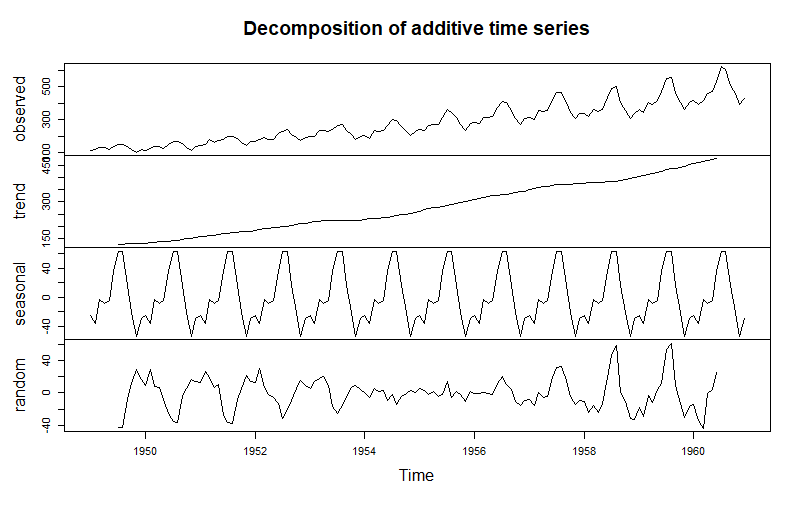

### 2-3. 요소 분해

시계열 데이터를 추세, 계절성, 잔차로 **분리(분해)** 하는 작업임.  
데이터 안에 뭐가 섞여 있는지 파악하는 데 아주 유용함.

---

#### 가법 모형 vs 승법 모형

요소들을 어떻게 합칠지에 대한 두 가지 관점임.

**가법 모형:**
$$Y = \text{추세} + \text{계절성} + \text{잔차}$$
- 계절성의 크기가 일정할 때 사용
- ex) 매년 여름마다 판매량이 딱 100개씩 늘어남

**승법 모형:**
$$Y = \text{추세} \times \text{계절성} \times \text{잔차}$$
- 계절성의 크기가 **추세에 비례**해서 커질 때 사용
- ex) 판매량이 많아질수록 여름 피크도 같이 커짐
- 로그 변환하면 가법 모형으로 바꿀 수 있음

---

#### seasonal_decompose vs STL

| | seasonal_decompose | STL |
|-|-------------------|-----|
| 방식 | 단순 이동평균 기반 | Loess 회귀 기반 |
| 계절성 주기 | 고정 | 유연하게 변할 수 있음 |
| 이상치에 강건함 | 약함 | 강함 (robust 옵션) |
| 사용 난이도 | 쉬움 | 약간 복잡 |



계절성이 시간에 따라 변하거나 이상치가 많은 데이터라면 STL이 더 나음

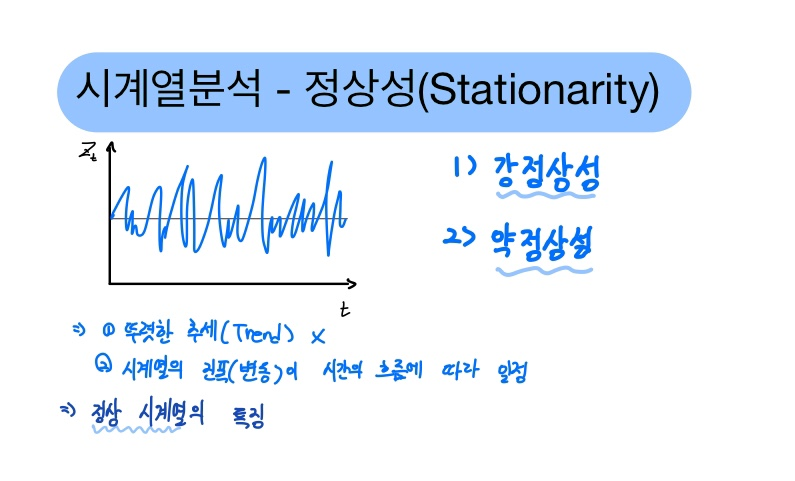

---

## 3. 정상성 판단

### 3-1. 정상성의 정의

**정상성**은 시계열의 통계적 특성이 시간이 지나도 변하지 않는 성질임.

쉽게 말해, 데이터를 어느 시점에서 잘라도 평균, 분산, 자기상관 구조가 비슷하면 정상 시계열임.

왜 중요하냐면 AR, MA, ARMA 같은 전통적인 시계열 모델들이 **정상성을 전제로** 동작하기 때문!

---

**강한 정상성 vs 약한 정상성:**

| | 강한 정상성 | 약한 정상성 |
|-|-----------|------------|
| 조건 | 결합 분포 전체가 시간 불변 | 평균, 분산, 공분산만 시간 불변 |
| 현실에서 | 만족하기 매우 어려움 | 실제로 주로 이걸 사용함 |

실무에서는 약한 정상성만 확인해도 충분하다고 한다

### 3-2. 정상성 판단 방법

**시각적 판단:**

그래프로 대충 봐도 판단할 수 있음.
- 평균이 시간에 따라 증가/감소 -> 비정상
- 분산이 시간에 따라 커지거나 작아짐 -> 비정상
- 자기상관 그래프가 천천히 감소함 -> 비정상 가능성 有

**통계적 판단**

가장 많이 쓰는 게 **ADF 검정**

- 귀무가설: "이 시계열은 비정상이다 (단위근이 있다)"
- p-value < 0.05 -> 귀무가설 기각 -> **정상 시계열**
- p-value ≥ 0.05 -> 비정상 시계열일 가능성



### 3-3. 정상성 확보 방법

비정상 시계열이라면 정상화 작업이 필요

| 방법 | 효과 | 사용 상황 |
|------|------|----------|
| **차분** | 추세 제거 | 평균이 변하는 경우 |
| **로그 변환** | 분산 안정화 | 분산이 점점 커지는 경우 |
| **계절 차분** | 계절성 제거 | 계절 패턴이 강한 경우 |

```python
# 1차 차분
df['diff'] = df['value'].diff(1)

# 로그 변환 후 차분
import numpy as np
df['log_diff'] = np.log(df['value']).diff(1)

# 계절 차분 (주기 12)
df['seasonal_diff'] = df['value'].diff(12)
```

차분 후에 다시 ADF 검정으로 정상성 확인할 것

---

## 4. 단변량 시계열 분석

하나의 변수만 가지고 분석하는 방식임.

### 4-1. 안정적 시계열 분석 (정상 시계열용)

#### AR

**AR** 은 **과거의 자기 자신 값**으로 현재를 예측하는 모델임.

$$Y_t = c + \phi_1 Y_{t-1} + \phi_2 Y_{t-2} + \cdots + \phi_p Y_{t-p} + \epsilon_t$$

- $p$: 몇 시점 전까지 볼지 (차수)
- "어제 주가가 높았으면 오늘도 높을 것이다" 같은 논리

---

#### MA

**MA** 는 **과거의 예측 오차**로 현재를 예측하는 모델임.

$$Y_t = c + \epsilon_t + \theta_1 \epsilon_{t-1} + \theta_2 \epsilon_{t-2} + \cdots + \theta_q \epsilon_{t-q}$$

- $q$: 몇 시점 전 오차까지 볼지 (차수)
- 과거에 얼마나 "틀렸는지"를 기억해서 보정하는 방식

---

#### AR, MA의 전제 조건

둘 다 **정상 시계열**에서만 제대로 동작함.

- AR: **정상성** + **가역성** 조건 만족해야 함
- MA: **정상성** + **식별 가능성** 조건 만족해야 함
- 비정상 시계열에 그냥 쓰면 쓰레기 결과가 나온다 -> 차분 등으로 정상화 먼저!

---

#### ARMA

AR과 MA를 합친 모델

$$Y_t = c + \sum_{i=1}^{p} \phi_i Y_{t-i} + \sum_{j=1}^{q} \theta_j \epsilon_{t-j} + \epsilon_t$$

- ARMA(p, q) 형태로 표기
- AR만 쓰거나 MA만 쓰는 것보다 더 유연하게 패턴을 잡을 수 있음
- **정상 시계열 전용**

#### 차수 결정 방법: 자기상관 함수

p, q를 뭘로 설정할지 결정하는 데 쓰는 도구임.

**ACF**
- 현재 값과 k시점 전 값의 상관관계
- MA 모델의 차수 q 결정에 활용
- ACF가 lag q 이후에 뚝 끊기면 -> MA(q)

**PACF**
- 중간 시점의 영향을 제거한 순수한 상관관계
- AR 모델의 차수 p 결정에 활용
- PACF가 lag p 이후에 뚝 끊기면 -> AR(p)


| 패턴 | AR | MA | ARMA |
|------|----|----|------|
| ACF | 서서히 감소 | lag q 이후 절단 | 서서히 감소 |
| PACF | lag p 이후 절단 | 서서히 감소 | 서서히 감소 |

### 4-2. 불안정 시계열 분석

비정상 시계열을 다룰 수 있는 모델

#### ARIMA

ARMA에 **차분** 을 추가한 모델임. 비정상 시계열을 차분으로 정상화한 뒤 ARMA 적용하는 것과 같음

**ARIMA(p, d, q):**
- p: AR 차수
- d: 차분 횟수 (몇 번 차분해야 정상이 되는지)
- q: MA 차수


---

#### SARIMA

ARIMA에 **계절성**까지 추가한 모델임.

**SARIMA(p, d, q)(P, D, Q, s):**
- 앞 (p, d, q): 일반 ARIMA 파라미터
- 뒤 (P, D, Q): 계절성 AR, 차분, MA 차수
- s: 계절 주기 (월별이면 12, 분기면 4)


계절성 패턴이 뚜렷한 데이터(월별 매출, 기온 등)엔 ARIMA보다 SARIMA가 훨씬 잘 맞음.

---

## 5. 다변량 시계열 분석

여러 변수를 동시에 분석하는 방식! 변수들이 서로 영향을 주고받을 때 사용함.

### VAR
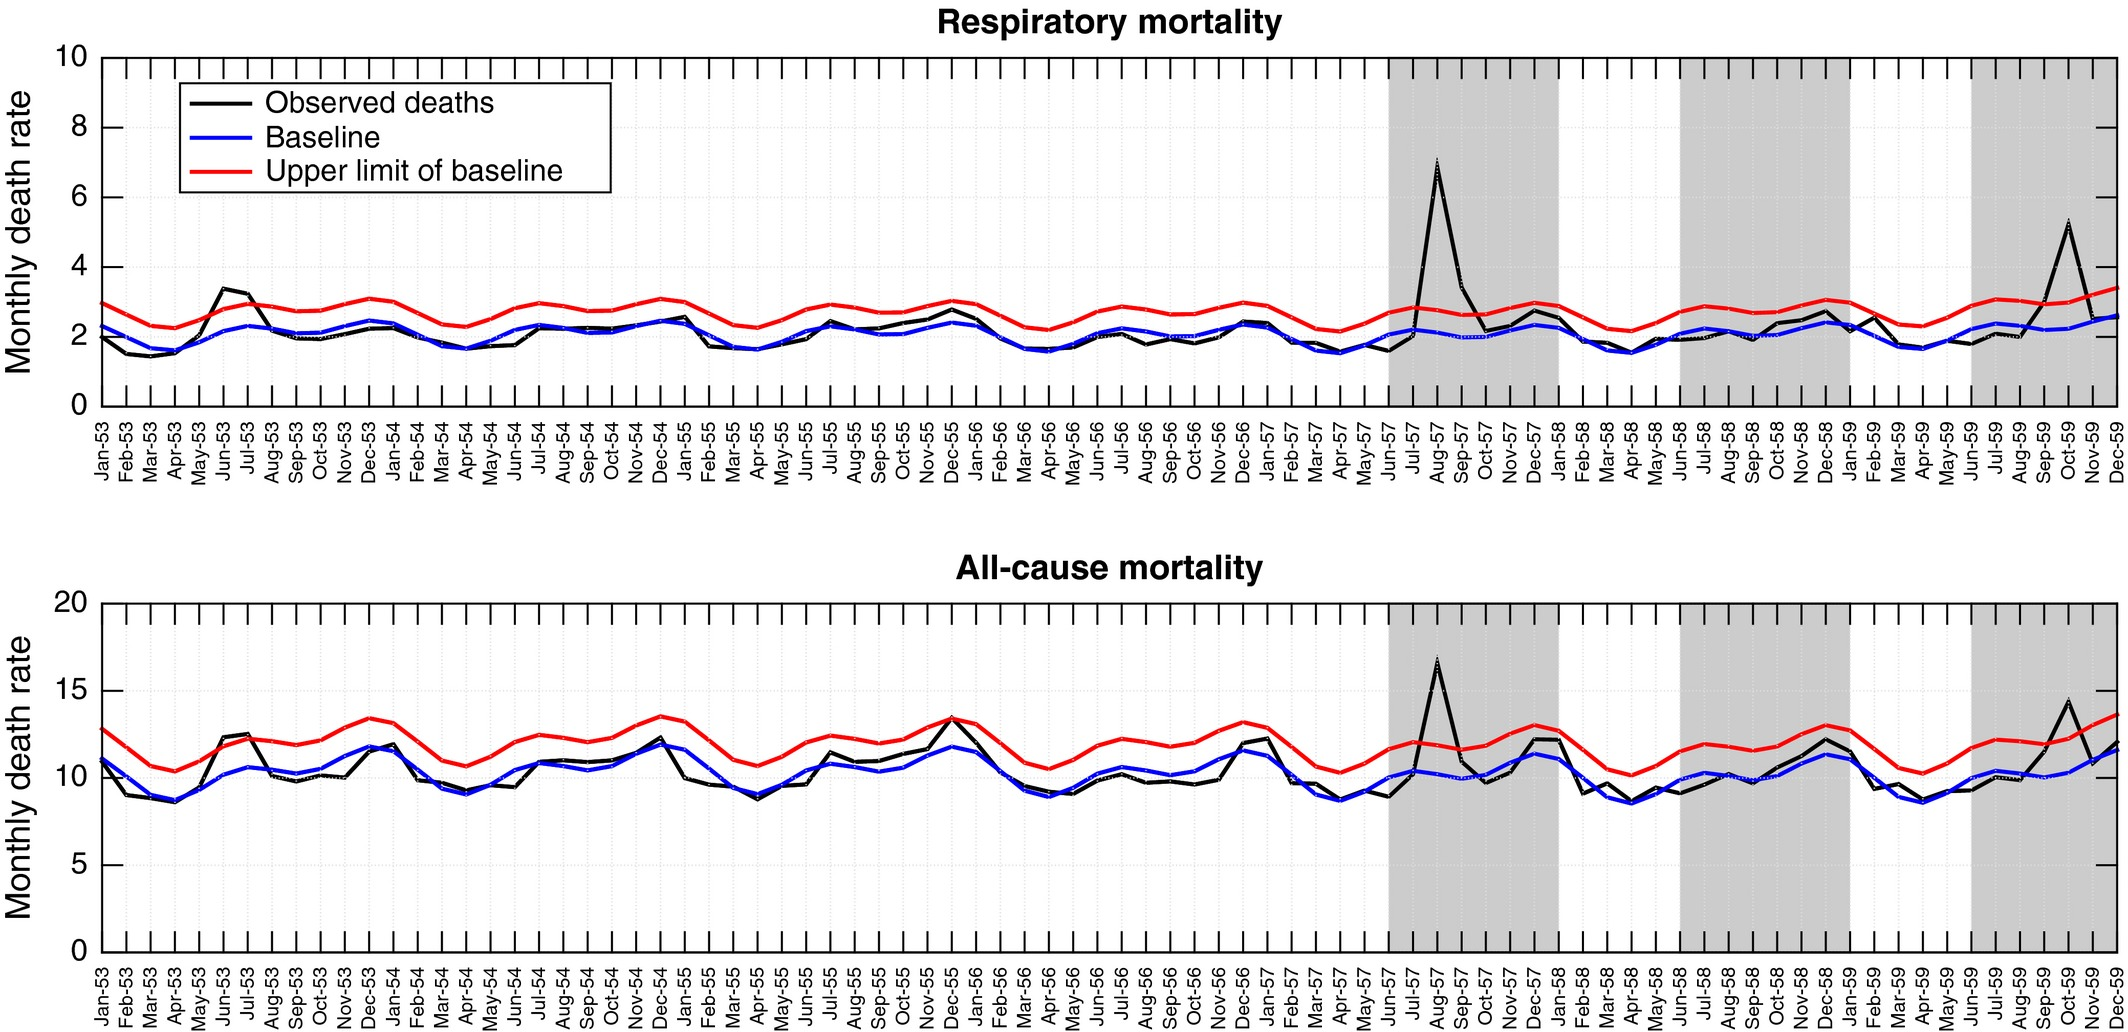

**VAR** 은 AR 모델을 여러 변수로 확장한 것임.  
각 변수가 자기 자신의 과거 값뿐만 아니라 **다른 변수들의 과거 값**에도 영향을 받는다고 가정함.

ex) 금리, 환율, 주가를 동시에 분석할 때  
-. 금리가 오르면 환율이 바뀌고, 그게 주가에 영향을 주는 관계를 한 번에 모델링

$$Y_t = c + A_1 Y_{t-1} + A_2 Y_{t-2} + \cdots + A_p Y_{t-p} + \epsilon_t$$

여기서 $Y_t$는 여러 변수들의 벡터임.


**주의:** VAR도 모든 변수가 **정상 시계열**이어야 함. 비정상이면 차분 후 사용.

---

## 6. 딥러닝을 활용한 시계열 분석

전통적인 통계 모델은 선형 관계 위주라 복잡한 패턴을 잡기 어려움.  
딥러닝은 비선형 패턴, 다변량 복잡한 관계, 대용량 데이터 처리에 강점이 있음.

---

### RNN

시퀀스 데이터를 처리하기 위해 설계된 신경망임.  
**이전 시점의 은닉 상태**를 다음 시점으로 넘겨줘서 시간 흐름을 기억하는 구조임.


**한계**
- **기울기 소실 문제**: 시퀀스가 길어지면 먼 과거 정보가 사라짐
- 이를 보완한 게 **LSTM**, **GRU**임
  - LSTM: 게이트 구조로 중요한 정보를 선택적으로 기억/망각
  - GRU: LSTM보다 구조가 단순하고 계산이 빠름


---

### Transformer

원래 NLP용으로 나왔는데 시계열에도 아주 잘 쓰임.  
셀프 어텐션 덕분에 시퀀스 내 모든 시점 간의 관계를 한 번에 계산할 수 있음.

**RNN 대비 장점:**
- 병렬 처리 가능 → 학습이 훨씬 빠름
- 먼 과거 정보도 직접 참조 가능 (기울기 소실 없음)

**시계열 특화 모델들:**
- **Informer**: 긴 시퀀스를 효율적으로 처리
- **Autoformer**: 계절성을 자동으로 분해
- **PatchTST**: 시계열을 패치 단위로 쪼개서 처리

---

### 파운데이션 모델
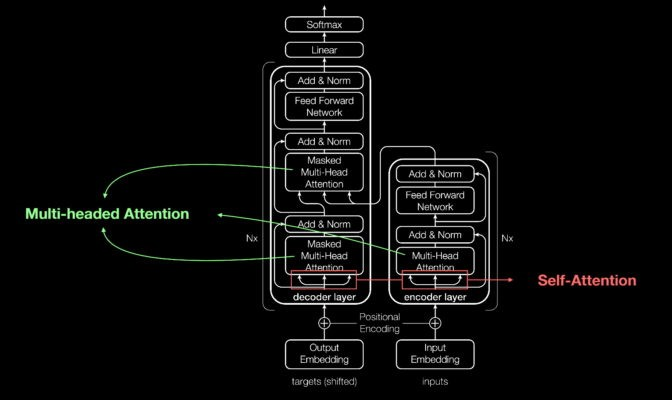

최근 LLM처럼 **시계열 전용 초대규모 사전학습 모델**이 등장하고 있음.  
다양한 도메인의 시계열 데이터로 사전학습하고, 새로운 태스크에 파인튜닝하거나 바로 쓰는 방식임.

**대표 모델**
- **TimeGPT**: 시계열 전용 GPT. API 형태로 제공됨
- **Lag-Llama**: 확률적 예측에 특화
- **Moirai**: 여러 주기, 여러 변수 동시 처리 가능
- **CHRONOS**: 언어 모델 구조를 시계열에 그대로 적용

**특징**
- 학습 데이터 없이도 새로운 시계열에 바로 예측 가능
- 도메인 지식 없이도 준수한 성능
- 아직 특정 도메인에서는 잘 튜닝된 ARIMA/LSTM보다 못한 경우도 있음

---

**딥러닝 모델 비교**

| 모델 | 장점 | 단점 |
|------|------|------|
| RNN/LSTM/GRU | 직관적, 구현 쉬움 | 긴 시퀀스에서 성능 저하 |
| Transformer | 장거리 의존성, 병렬 처리 | 데이터 많이 필요, 계산 비용 큼 |
| 파운데이션 모델 | 제로샷 가능, 범용 | 해석 어렵고 특화 태스크에선 아직 불안정 |

---

## 요약

```
시계열 분석 흐름

① 데이터 이해
   └── 추세 / 계절성 / 순환 / 불규칙으로 구성됨

② 전처리
   ├── 결측치: 전방채우기, 선형보간 등
   ├── 이상치: 탐지 후 의미 파악이 먼저
   ├── EDA: 시각화, 이동평균, 자기상관 확인
   └── 요소 분해: seasonal_decompose / STL
                 (가법 or 승법 모형 선택)

③ 정상성 판단
   ├── 시각 확인 + ADF 검정
   └── 비정상이면 차분 / 로그변환으로 정상화

④ 모델링
   ├── 단변량 + 정상: AR / MA / ARMA
   │               (ACF, PACF로 차수 결정)
   ├── 단변량 + 비정상: ARIMA / SARIMA
   ├── 다변량: VAR
   └── 딥러닝: RNN(LSTM/GRU) / Transformer / 파운데이션 모델
```

# 감사합니다 ~~ 🦭🦭🦭